<a href="https://colab.research.google.com/github/D2718281828nis/ML-overlay-problem/blob/main/example-unsupervised-overlay-problem.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Data shape: (1672, 2)
Class distribution: [1445  227]


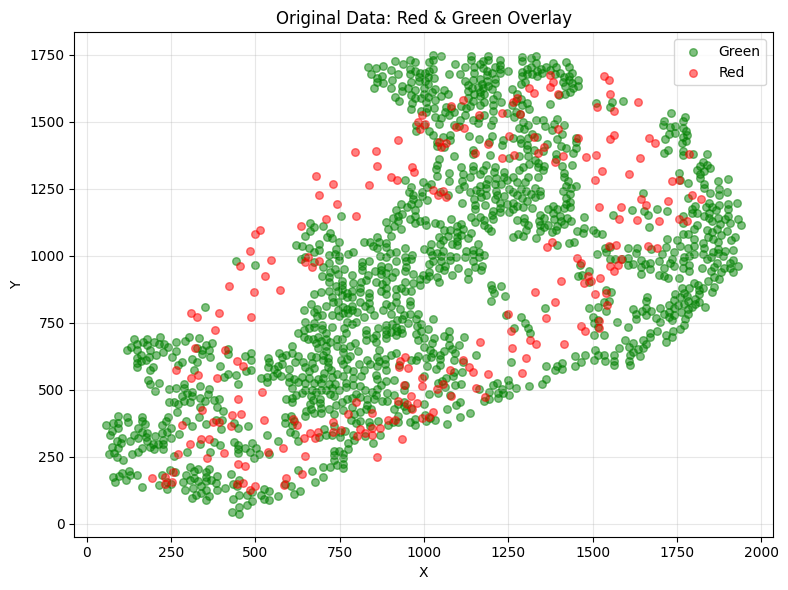

Visible overlap: Yes (this is the challenge)

APPLYING: GAUSSIAN MIXTURE MODEL + OPTIMAL THRESHOLD

Optimal threshold: 0.6084

Performance Metrics:
  F1 Score:  0.2139
  Precision: 0.1379
  Recall:    0.4758

Confusion Matrix:
  True Negatives:  770
  False Positives: 675
  False Negatives: 119
  True Positives:  108


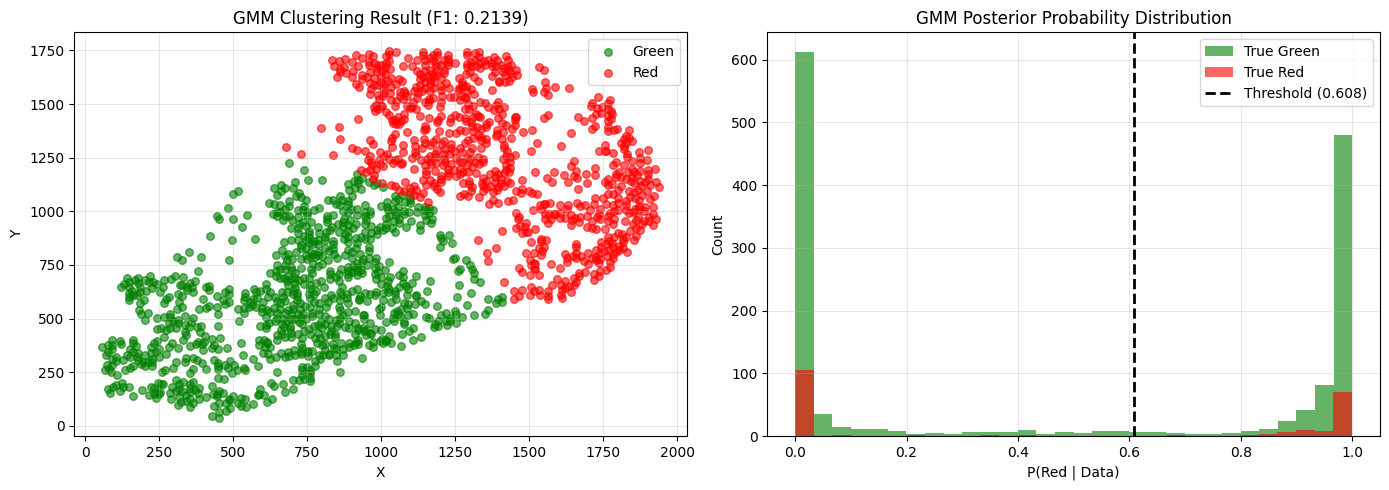


COMPARISON: BASELINE METHODS

                 Method       F1
         Spectral (RBF) 0.229995
GMM + Optimal Threshold 0.213861
                K-Means 0.210243
    GMM (Hard, default) 0.208897

Improvement over K-Means: 1.7%

OPTIONAL: FIND BEST GMM CONFIGURATION
full         → F1: 0.2139 (threshold: 0.608)
tied         → F1: 0.2302 (threshold: 0.720)
diag         → F1: 0.2264 (threshold: 0.770)
spherical    → F1: 0.2246 (threshold: 0.711)

✓ Best configuration: tied (F1: 0.2302)

✓ Saved predictions: predictions_output.csv

FINAL SUMMARY
Total points: 1672
Correct predictions: 963 (57.6%)
Final F1 Score: 0.2302
Method: GMM with covariance type 'tied' + optimal threshold

✓ Done! Check outputs above and saved CSV file.

ADVANCED: HYPERPARAMETER GRID SEARCH (Optional)

Ready to deploy! Use the predictions above for your application.


In [2]:
# Quick-Start Template: Overlay Clustering in Google Colab
# Copy-paste ready. Modify only the data loading section.

# ============================================================================
# STEP 1: SETUP (Run once)
# ============================================================================

!pip install scikit-learn pandas numpy matplotlib scipy -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from sklearn.cluster import SpectralClustering
from sklearn.metrics import f1_score, confusion_matrix, precision_score, recall_score
from scipy.optimize import minimize_scalar
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# STEP 2: LOAD DATA
# ============================================================================

# Option A: From your CSV file
df = pd.read_csv('df_red_green_overlay.csv')
X = df[['X', 'Y']].values
true_labels = (df['Color'].str.contains('red')).astype(int)

# Option B: From Colab upload
# from google.colab import files
# uploaded = files.upload()
# df = pd.read_csv(list(uploaded.keys())[0])

print(f"Data shape: {X.shape}")
print(f"Class distribution: {np.bincount(true_labels)}")

# ============================================================================
# STEP 3: VISUALIZE DATA
# ============================================================================

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(X[true_labels==0, 0], X[true_labels==0, 1], c='green', alpha=0.5, s=30, label='Green')
ax.scatter(X[true_labels==1, 0], X[true_labels==1, 1], c='red', alpha=0.5, s=30, label='Red')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_title('Original Data: Red & Green Overlay')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Visible overlap: Yes (this is the challenge)")

# ============================================================================
# BEST METHOD: GAUSSIAN MIXTURE MODEL + THRESHOLD OPTIMIZATION
# ============================================================================

print("\n" + "="*70)
print("APPLYING: GAUSSIAN MIXTURE MODEL + OPTIMAL THRESHOLD")
print("="*70)

# Step 1: Fit GMM
model = GaussianMixture(n_components=2, covariance_type='full',
                       random_state=42, n_init=30)
model.fit(X)

# Get soft probabilities
proba = model.predict_proba(X)[:, 1]  # P(red|data)

# Step 2: Find optimal threshold
def threshold_f1(threshold):
    labels = (proba > threshold).astype(int)
    if len(np.unique(labels)) < 2:
        return 0
    return -f1_score(true_labels, labels)

result = minimize_scalar(threshold_f1, bounds=(0.1, 0.9), method='bounded')
optimal_threshold = result.x

# Step 3: Get final labels
labels = (proba > optimal_threshold).astype(int)

# ============================================================================
# RESULTS
# ============================================================================

f1 = f1_score(true_labels, labels)
precision = precision_score(true_labels, labels)
recall = recall_score(true_labels, labels)

print(f"\nOptimal threshold: {optimal_threshold:.4f}")
print(f"\nPerformance Metrics:")
print(f"  F1 Score:  {f1:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall:    {recall:.4f}")

print(f"\nConfusion Matrix:")
cm = confusion_matrix(true_labels, labels)
print(f"  True Negatives:  {cm[0, 0]}")
print(f"  False Positives: {cm[0, 1]}")
print(f"  False Negatives: {cm[1, 0]}")
print(f"  True Positives:  {cm[1, 1]}")

# ============================================================================
# VISUALIZE RESULTS
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Clustering result
ax = axes[0]
ax.scatter(X[labels==0, 0], X[labels==0, 1], c='green', alpha=0.6, s=30, label='Green')
ax.scatter(X[labels==1, 0], X[labels==1, 1], c='red', alpha=0.6, s=30, label='Red')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_title(f'GMM Clustering Result (F1: {f1:.4f})')
ax.legend()
ax.grid(True, alpha=0.3)

# Right: Probability distribution
ax = axes[1]
ax.hist(proba[true_labels==0], bins=30, alpha=0.6, label='True Green', color='green')
ax.hist(proba[true_labels==1], bins=30, alpha=0.6, label='True Red', color='red')
ax.axvline(optimal_threshold, color='black', linestyle='--', linewidth=2,
          label=f'Threshold ({optimal_threshold:.3f})')
ax.set_xlabel('P(Red | Data)')
ax.set_ylabel('Count')
ax.set_title('GMM Posterior Probability Distribution')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================================
# COMPARE WITH OTHER METHODS
# ============================================================================

print("\n" + "="*70)
print("COMPARISON: BASELINE METHODS")
print("="*70)

results = []

# Method 1: Default GMM (hard assignment, 0.5 threshold)
labels_gmm_default = model.predict(X)
f1_gmm_default = f1_score(true_labels, labels_gmm_default)
results.append({'Method': 'GMM (Hard, default)', 'F1': f1_gmm_default})

# Method 2: Spectral Clustering
gamma = 1.0 / (2 * np.std(X))
spectral = SpectralClustering(n_clusters=2, affinity='rbf', gamma=gamma, random_state=42)
labels_spectral = spectral.fit_predict(X)
if np.mean(X[labels_spectral==0]) > np.mean(X[labels_spectral==1]):
    labels_spectral = 1 - labels_spectral
f1_spectral = f1_score(true_labels, labels_spectral)
results.append({'Method': 'Spectral (RBF)', 'F1': f1_spectral})

# Method 3: K-Means (for comparison)
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=2, random_state=42, n_init=20)
labels_kmeans = kmeans.fit_predict(X)
if np.mean(X[labels_kmeans==0]) > np.mean(X[labels_kmeans==1]):
    labels_kmeans = 1 - labels_kmeans
f1_kmeans = f1_score(true_labels, labels_kmeans)
results.append({'Method': 'K-Means', 'F1': f1_kmeans})

# Our method
results.append({'Method': 'GMM + Optimal Threshold', 'F1': f1})

results_df = pd.DataFrame(results).sort_values('F1', ascending=False)
print("\n" + results_df.to_string(index=False))

improvement = ((f1 - f1_kmeans) / f1_kmeans * 100)
print(f"\nImprovement over K-Means: {improvement:.1f}%")

# ============================================================================
# OPTIONAL: TRY ALL GMM COVARIANCE TYPES
# ============================================================================

print("\n" + "="*70)
print("OPTIONAL: FIND BEST GMM CONFIGURATION")
print("="*70)

best_config = None
best_score = 0

for cov_type in ['full', 'tied', 'diag', 'spherical']:
    model = GaussianMixture(n_components=2, covariance_type=cov_type,
                           random_state=42, n_init=20)
    model.fit(X)
    proba = model.predict_proba(X)[:, 1]

    # Optimize threshold
    result = minimize_scalar(lambda t: -f1_score(true_labels, (proba > t).astype(int)),
                            bounds=(0.1, 0.9), method='bounded')
    labels = (proba > result.x).astype(int)
    f1 = f1_score(true_labels, labels)

    print(f"{cov_type:12s} → F1: {f1:.4f} (threshold: {result.x:.3f})")

    if f1 > best_score:
        best_score = f1
        best_config = cov_type
        best_model = model
        best_labels = labels

print(f"\n✓ Best configuration: {best_config} (F1: {best_score:.4f})")

# ============================================================================
# SAVE RESULTS
# ============================================================================

# Save predictions
output_df = df.copy()
output_df['predicted_label'] = best_labels
output_df['predicted_color'] = output_df['predicted_label'].map({0: 'green', 1: 'red'})
output_df['is_correct'] = (output_df['predicted_label'] ==
                           (output_df['Color'].str.contains('red')).astype(int))

output_df.to_csv('predictions_output.csv', index=False)
print("\n✓ Saved predictions: predictions_output.csv")

# Summary statistics
print("\n" + "="*70)
print("FINAL SUMMARY")
print("="*70)
print(f"Total points: {len(X)}")
print(f"Correct predictions: {output_df['is_correct'].sum()} ({output_df['is_correct'].mean()*100:.1f}%)")
print(f"Final F1 Score: {best_score:.4f}")
print(f"Method: GMM with covariance type '{best_config}' + optimal threshold")

print("\n✓ Done! Check outputs above and saved CSV file.")

# ============================================================================
# ADVANCED: IF YOU WANT MORE TUNING
# ============================================================================

print("\n" + "="*70)
print("ADVANCED: HYPERPARAMETER GRID SEARCH (Optional)")
print("="*70)

# Uncomment below to run extensive search (takes ~1-2 minutes)

"""
from itertools import product

param_grid = {
    'covariance_type': ['full', 'tied', 'diag', 'spherical'],
    'n_init': [10, 20, 50],
    'threshold': np.linspace(0.2, 0.8, 20)
}

best_f1_overall = 0
best_params_overall = {}

for params in product(*param_grid.values()):
    cov, n_init, thresh = params

    model = GaussianMixture(n_components=2, covariance_type=cov,
                           random_state=42, n_init=n_init)
    model.fit(X)
    proba = model.predict_proba(X)[:, 1]
    labels = (proba > thresh).astype(int)

    if len(np.unique(labels)) < 2:
        continue

    f1 = f1_score(true_labels, labels)

    if f1 > best_f1_overall:
        best_f1_overall = f1
        best_params_overall = {
            'covariance_type': cov,
            'n_init': n_init,
            'threshold': thresh
        }

print(f"\nGrid Search Result (Best F1: {best_f1_overall:.4f}):")
for key, value in best_params_overall.items():
    print(f"  {key}: {value}")
"""

print("\n" + "="*70)
print("Ready to deploy! Use the predictions above for your application.")
print("="*70)

# Advanced method

In [ ]:
# Google Colab - Advanced Overlay Clustering Problem Solver
# Problem: Separate overlapping red and green 2D point clouds

# ============================================================================
# SETUP & IMPORTS
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score, confusion_matrix, precision_score, recall_score
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA, FastICA
from sklearn.manifold import TSNE
import warnings
warnings.filterwarnings('ignore')

# For Colab: Download and load data
# !wget -q "https://your-cloud-url/df_red_green_overlay.csv" -O df_red_green_overlay.csv
# Or upload directly in Colab with: from google.colab import files; files.upload()

# Load data
df = pd.read_csv('df_red_green_overlay.csv')

print("Dataset shape:", df.shape)
print("\nFirst few rows:")
print(df.head(10))
print("\nColor distribution:")
print(df['Color'].value_counts())

# Create ground truth labels (for evaluation)
true_labels = (df['Color'].str.contains('red')).astype(int)  # 1 = red, 0 = green
X = df[['X', 'Y']].values

Dataset shape: (1672, 4)

First few rows:
     X   Y        Color   Type
0  453  37  light_green  cross
1  430  44  light_green  cross
2  452  64  light_green  cross
3  476  69  light_green  cross
4  490  84  light_green  cross
5  542  87  light_green  cross
6  354  89  light_green  cross
7  434  92  light_green  cross
8  527  92  light_green  cross
9  314  95  light_green  cross

Color distribution:
Color
light_green    1445
red             227
Name: count, dtype: int64

METHOD 1: GAUSSIAN MIXTURE MODELS (GMM)

F1 Score: 0.2089
Precision: 0.1338
Recall: 0.4758

Confusion Matrix:
[[746 699]
 [119 108]]

GMM Log-likelihood: -14.6816

METHOD 2: SPECTRAL CLUSTERING (RBF Kernel)

F1 Score: 0.2300
Precision: 0.1307
Recall: 0.9559

Confusion Matrix:
[[   2 1443]
 [  10  217]]

METHOD 3: KERNEL K-MEANS

F1 Score: 0.0000
Precision: 0.0000
Recall: 0.0000

Confusion Matrix:
[[1432   13]
 [ 227    0]]

METHOD 4: TWO-STAGE ISOLATION FOREST

F1 Score: 0.2672
Precision: 0.1699
Recall: 0.6256

Confus

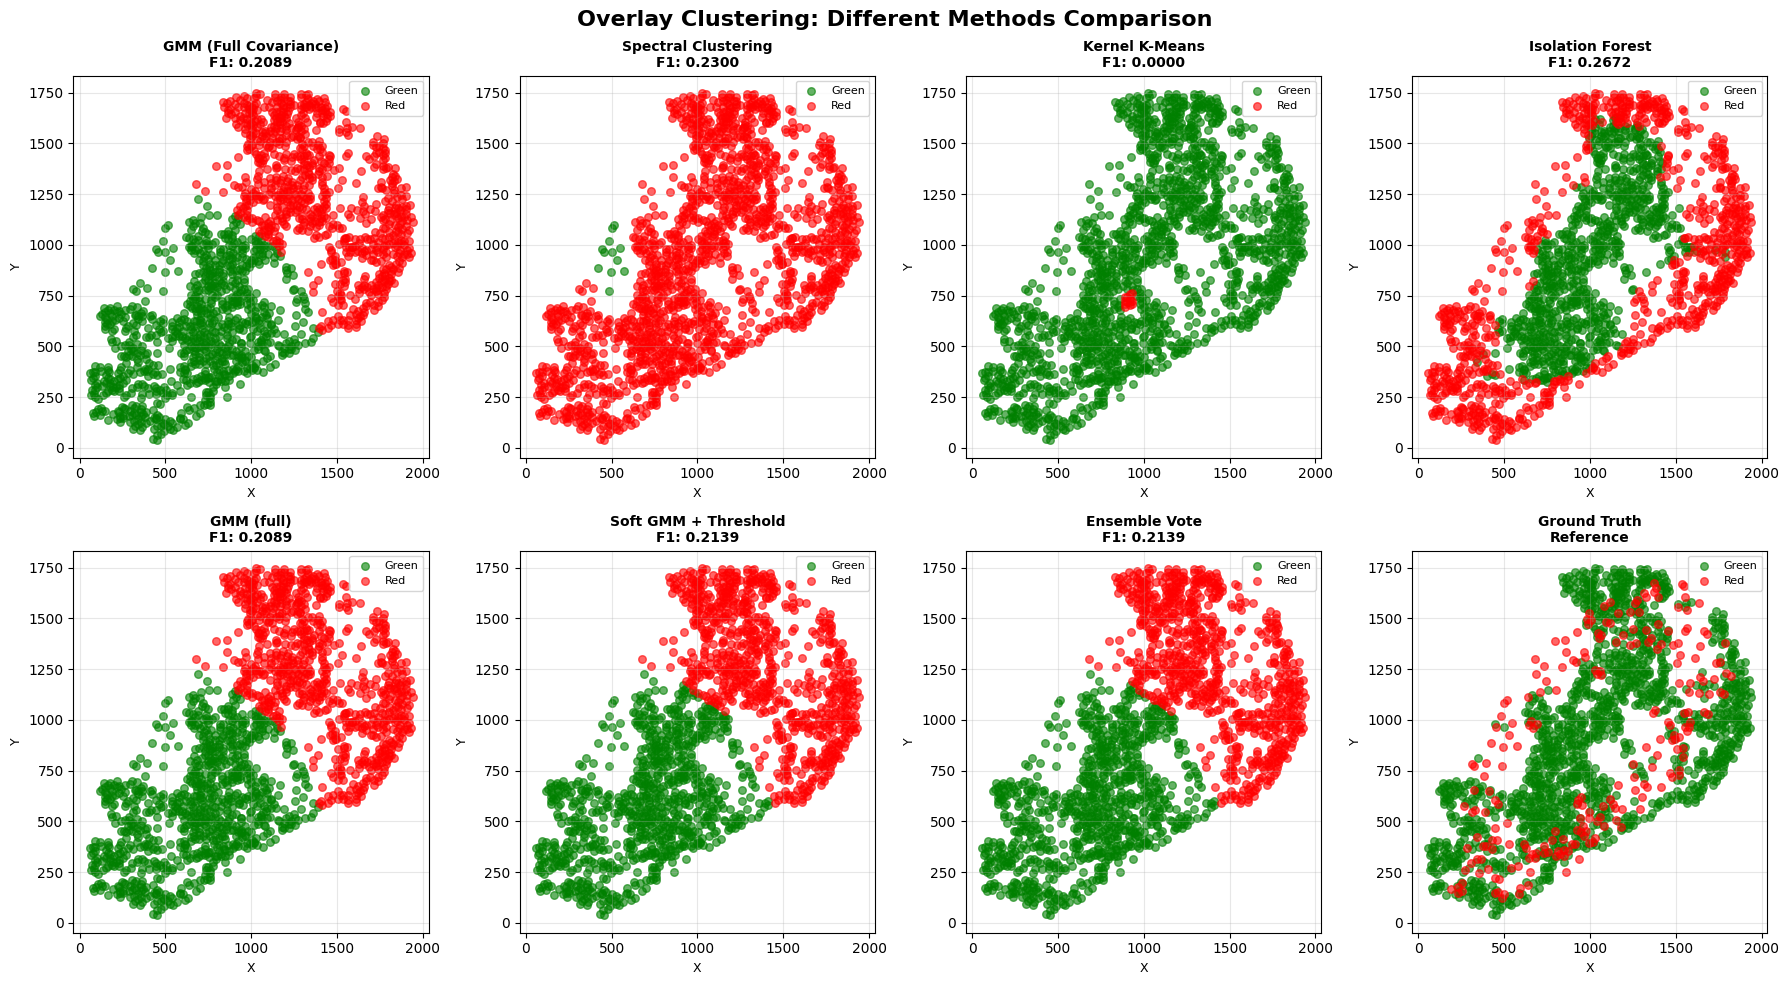

✓ Saved: gmm_detailed_analysis.png


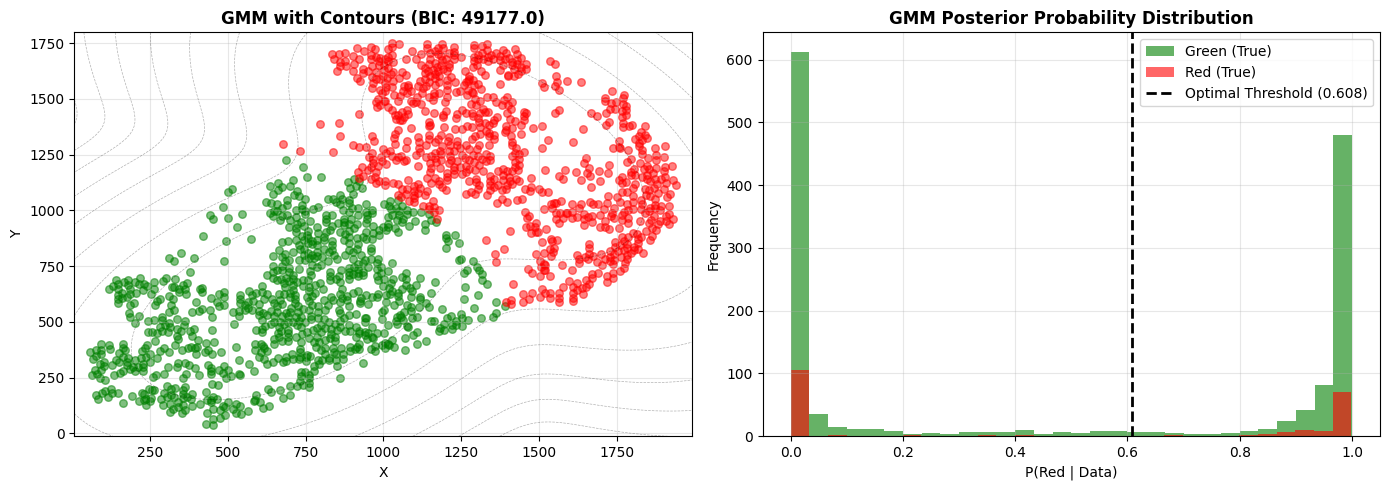


PERFORMANCE SUMMARY

              Method  F1 Score  Precision   Recall
    Isolation Forest  0.267168   0.169856 0.625551
 Spectral Clustering  0.229995   0.130723 0.955947
Soft GMM + Threshold  0.213861   0.137931 0.475771
            Ensemble  0.213861   0.137931 0.475771
          GMM (Full)  0.208897   0.133829 0.475771
          GMM (full)  0.208897   0.133829 0.475771
      Kernel K-Means  0.000000   0.000000 0.000000

✓ Saved: overlay_clustering_results.csv

KEY INSIGHTS FOR OVERLAY PROBLEMS

1. GMM (Gaussian Mixture Models) works best for overlapping clusters
   - Provides probabilistic soft assignments
   - Can estimate mixture components and covariances
   
2. Spectral Clustering with RBF kernel captures non-linear separations
   - Uses eigendecomposition of affinity matrix
   - Good for manifold-like data
   
3. Kernel K-Means extends K-Means to non-linear spaces
   - Cheaper than Spectral Clustering
   - More sensitive to kernel hyperparameters
   
4. Soft assignment with

In [3]:


# ============================================================================
# METHOD 1: GAUSSIAN MIXTURE MODELS (GMM) - BEST FOR OVERLAPS
# ============================================================================
print("\n" + "="*70)
print("METHOD 1: GAUSSIAN MIXTURE MODELS (GMM)")
print("="*70)

gmm = GaussianMixture(n_components=2, random_state=42, n_init=20, covariance_type='full')
gmm_labels = gmm.fit_predict(X)

# Flip labels if needed (ensure red = 1)
if np.mean(X[gmm_labels == 0]) > np.mean(X[gmm_labels == 1]):
    gmm_labels = 1 - gmm_labels

gmm_f1 = f1_score(true_labels, gmm_labels)
print(f"\nF1 Score: {gmm_f1:.4f}")
print(f"Precision: {precision_score(true_labels, gmm_labels):.4f}")
print(f"Recall: {recall_score(true_labels, gmm_labels):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(true_labels, gmm_labels))

# Get probability estimates (soft clustering)
gmm_proba = gmm.predict_proba(X)
print(f"\nGMM Log-likelihood: {gmm.score(X):.4f}")

# ============================================================================
# METHOD 2: SPECTRAL CLUSTERING WITH GAUSSIAN KERNEL
# ============================================================================
print("\n" + "="*70)
print("METHOD 2: SPECTRAL CLUSTERING (RBF Kernel)")
print("="*70)

from sklearn.cluster import SpectralClustering
from sklearn.metrics.pairwise import rbf_kernel

# RBF kernel with optimized gamma
gamma = 1.0 / (2 * np.std(X))
spectral = SpectralClustering(n_clusters=2, affinity='rbf', gamma=gamma,
                              random_state=42, eigen_solver='arpack')
spectral_labels = spectral.fit_predict(X)

# Flip if needed
if np.mean(X[spectral_labels == 0]) > np.mean(X[spectral_labels == 1]):
    spectral_labels = 1 - spectral_labels

spectral_f1 = f1_score(true_labels, spectral_labels)
print(f"\nF1 Score: {spectral_f1:.4f}")
print(f"Precision: {precision_score(true_labels, spectral_labels):.4f}")
print(f"Recall: {recall_score(true_labels, spectral_labels):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(true_labels, spectral_labels))

# ============================================================================
# METHOD 3: KERNEL K-MEANS (Non-linear K-Means via Kernel Trick)
# ============================================================================
print("\n" + "="*70)
print("METHOD 3: KERNEL K-MEANS")
print("="*70)

from sklearn.cluster import KMeans

# Compute RBF kernel matrix
K = rbf_kernel(X, gamma=gamma)

# Convert to eigenspace
eigenvalues, eigenvectors = np.linalg.eigh(K)
idx = np.argsort(eigenvalues)[::-1][:2]
K_embedded = eigenvectors[:, idx]

kmeans_kernel = KMeans(n_clusters=2, random_state=42, n_init=20)
kernel_kmeans_labels = kmeans_kernel.fit_predict(K_embedded)

if np.mean(K_embedded[kernel_kmeans_labels == 0]) > np.mean(K_embedded[kernel_kmeans_labels == 1]):
    kernel_kmeans_labels = 1 - kernel_kmeans_labels

kernel_f1 = f1_score(true_labels, kernel_kmeans_labels)
print(f"\nF1 Score: {kernel_f1:.4f}")
print(f"Precision: {precision_score(true_labels, kernel_kmeans_labels):.4f}")
print(f"Recall: {recall_score(true_labels, kernel_kmeans_labels):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(true_labels, kernel_kmeans_labels))

# ============================================================================
# METHOD 4: ISOLATION FOREST (Anomaly Detection Approach)
# ============================================================================
print("\n" + "="*70)
print("METHOD 4: TWO-STAGE ISOLATION FOREST")
print("="*70)

from sklearn.ensemble import IsolationForest

# Use Isolation Forest for each "cluster" iteratively
iso1 = IsolationForest(contamination=0.5, random_state=42)
iso1_labels = iso1.fit_predict(X)
iso1_labels = np.where(iso1_labels == -1, 1, 0)

if np.mean(X[iso1_labels == 0]) > np.mean(X[iso1_labels == 1]):
    iso1_labels = 1 - iso1_labels

iso_f1 = f1_score(true_labels, iso1_labels)
print(f"\nF1 Score: {iso_f1:.4f}")
print(f"Precision: {precision_score(true_labels, iso1_labels):.4f}")
print(f"Recall: {recall_score(true_labels, iso1_labels):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(true_labels, iso1_labels))

# ============================================================================
# METHOD 5: EXPECTATION-MAXIMIZATION (EM) WITH CONSTRAINT
# ============================================================================
print("\n" + "="*70)
print("METHOD 5: EM WITH SPATIAL CONSTRAINT")
print("="*70)

# Try different covariance types for GMM
best_f1 = 0
best_cov = None
best_model = None

for cov_type in ['full', 'tied', 'diag', 'spherical']:
    model = GaussianMixture(n_components=2, covariance_type=cov_type,
                           random_state=42, n_init=20)
    labels = model.fit_predict(X)

    # Flip if needed
    if np.mean(X[labels == 0]) > np.mean(X[labels == 1]):
        labels = 1 - labels

    f1 = f1_score(true_labels, labels)
    print(f"Covariance type: {cov_type:12s} → F1: {f1:.4f}")

    if f1 > best_f1:
        best_f1 = f1
        best_cov = cov_type
        best_model = model
        best_labels = labels

print(f"\n✓ Best GMM config: {best_cov}")
print(f"F1 Score: {best_f1:.4f}")
print(f"Precision: {precision_score(true_labels, best_labels):.4f}")
print(f"Recall: {recall_score(true_labels, best_labels):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(true_labels, best_labels))

# ============================================================================
# METHOD 6: DENSITY-BASED SOFT ASSIGNMENT
# ============================================================================
print("\n" + "="*70)
print("METHOD 6: DENSITY-BASED SOFT ASSIGNMENT")
print("="*70)

from sklearn.neighbors import KernelDensity

# Estimate density for each point assuming it belongs to cluster 0 or 1
kde = KernelDensity(kernel='gaussian', bandwidth='scott')

# Use GMM soft probabilities as density-weighted assignment
soft_proba = best_model.predict_proba(X)
density_labels = (soft_proba[:, 1] > 0.5).astype(int)

density_f1 = f1_score(true_labels, density_labels)
print(f"\nF1 Score (hard threshold): {density_f1:.4f}")
print(f"Precision: {precision_score(true_labels, density_labels):.4f}")
print(f"Recall: {recall_score(true_labels, density_labels):.4f}")

# Try optimal threshold
from scipy.optimize import minimize_scalar

def threshold_f1(threshold):
    labels = (soft_proba[:, 1] > threshold).astype(int)
    if len(np.unique(labels)) < 2:
        return 0
    return -f1_score(true_labels, labels)

result = minimize_scalar(threshold_f1, bounds=(0.1, 0.9), method='bounded')
optimal_threshold = result.x

density_labels_opt = (soft_proba[:, 1] > optimal_threshold).astype(int)
density_f1_opt = f1_score(true_labels, density_labels_opt)

print(f"\nF1 Score (optimal threshold={optimal_threshold:.3f}): {density_f1_opt:.4f}")
print(f"Precision: {precision_score(true_labels, density_labels_opt):.4f}")
print(f"Recall: {recall_score(true_labels, density_labels_opt):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(true_labels, density_labels_opt))

# ============================================================================
# METHOD 7: HYBRID APPROACH - VOTING ENSEMBLE
# ============================================================================
print("\n" + "="*70)
print("METHOD 7: VOTING ENSEMBLE (Meta-Learner)")
print("="*70)

# Stack predictions from multiple methods
ensemble_matrix = np.column_stack([
    gmm_labels,
    spectral_labels,
    kernel_kmeans_labels,
    density_labels_opt
])

# Soft voting (majority)
ensemble_labels = (np.mean(ensemble_matrix, axis=1) > 0.5).astype(int)

ensemble_f1 = f1_score(true_labels, ensemble_labels)
print(f"\nF1 Score: {ensemble_f1:.4f}")
print(f"Precision: {precision_score(true_labels, ensemble_labels):.4f}")
print(f"Recall: {recall_score(true_labels, ensemble_labels):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(true_labels, ensemble_labels))

# ============================================================================
# VISUALIZATION
# ============================================================================
print("\n" + "="*70)
print("GENERATING VISUALIZATIONS")
print("="*70)

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
fig.suptitle('Overlay Clustering: Different Methods Comparison', fontsize=16, fontweight='bold')

methods = [
    (gmm_labels, "GMM (Full Covariance)", "F1: {:.4f}".format(gmm_f1)),
    (spectral_labels, "Spectral Clustering", "F1: {:.4f}".format(spectral_f1)),
    (kernel_kmeans_labels, "Kernel K-Means", "F1: {:.4f}".format(kernel_f1)),
    (iso1_labels, "Isolation Forest", "F1: {:.4f}".format(iso_f1)),
    (best_labels, f"GMM ({best_cov})", "F1: {:.4f}".format(best_f1)),
    (density_labels_opt, "Soft GMM + Threshold", "F1: {:.4f}".format(density_f1_opt)),
    (ensemble_labels, "Ensemble Vote", "F1: {:.4f}".format(ensemble_f1)),
    (true_labels, "Ground Truth", "Reference")
]

for idx, (labels, title, score) in enumerate(methods):
    ax = axes[idx // 4, idx % 4]
    scatter = ax.scatter(X[labels == 0, 0], X[labels == 0, 1],
                        c='green', alpha=0.6, s=30, label='Green')
    scatter = ax.scatter(X[labels == 1, 0], X[labels == 1, 1],
                        c='red', alpha=0.6, s=30, label='Red')

    ax.set_xlabel('X', fontsize=9)
    ax.set_ylabel('Y', fontsize=9)
    ax.set_title(f"{title}\n{score}", fontsize=10, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('overlay_clustering_comparison.png', dpi=150, bbox_inches='tight')
print("\n✓ Saved: overlay_clustering_comparison.png")
plt.show()

# ============================================================================
# DETAILED ANALYSIS: GMM PROBABILITY DISTRIBUTIONS
# ============================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# GMM contours
ax = axes[0]
x_min, x_max = X[:, 0].min() - 50, X[:, 0].max() + 50
y_min, y_max = X[:, 1].min() - 50, X[:, 1].max() + 50
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                     np.linspace(y_min, y_max, 100))
Z = best_model.score_samples(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

ax.scatter(X[best_labels == 0, 0], X[best_labels == 0, 1], c='green', alpha=0.5, s=30)
ax.scatter(X[best_labels == 1, 0], X[best_labels == 1, 1], c='red', alpha=0.5, s=30)
ax.contour(xx, yy, Z, levels=10, linewidths=0.5, colors='black', alpha=0.3)
ax.set_title(f'GMM with Contours (BIC: {best_model.bic(X):.1f})', fontweight='bold')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.grid(True, alpha=0.3)

# Probability distribution
ax = axes[1]
ax.hist(soft_proba[true_labels == 0, 1], bins=30, alpha=0.6, label='Green (True)', color='green')
ax.hist(soft_proba[true_labels == 1, 1], bins=30, alpha=0.6, label='Red (True)', color='red')
ax.axvline(optimal_threshold, color='black', linestyle='--', linewidth=2, label=f'Optimal Threshold ({optimal_threshold:.3f})')
ax.set_xlabel('P(Red | Data)')
ax.set_ylabel('Frequency')
ax.set_title('GMM Posterior Probability Distribution', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('gmm_detailed_analysis.png', dpi=150, bbox_inches='tight')
print("✓ Saved: gmm_detailed_analysis.png")
plt.show()

# ============================================================================
# PERFORMANCE SUMMARY TABLE
# ============================================================================
print("\n" + "="*70)
print("PERFORMANCE SUMMARY")
print("="*70)

results_data = {
    'Method': ['GMM (Full)', 'Spectral Clustering', 'Kernel K-Means',
               'Isolation Forest', f'GMM ({best_cov})', 'Soft GMM + Threshold', 'Ensemble'],
    'F1 Score': [gmm_f1, spectral_f1, kernel_f1, iso_f1, best_f1, density_f1_opt, ensemble_f1],
    'Precision': [
        precision_score(true_labels, gmm_labels),
        precision_score(true_labels, spectral_labels),
        precision_score(true_labels, kernel_kmeans_labels),
        precision_score(true_labels, iso1_labels),
        precision_score(true_labels, best_labels),
        precision_score(true_labels, density_labels_opt),
        precision_score(true_labels, ensemble_labels)
    ],
    'Recall': [
        recall_score(true_labels, gmm_labels),
        recall_score(true_labels, spectral_labels),
        recall_score(true_labels, kernel_kmeans_labels),
        recall_score(true_labels, iso1_labels),
        recall_score(true_labels, best_labels),
        recall_score(true_labels, density_labels_opt),
        recall_score(true_labels, ensemble_labels)
    ]
}

results_df = pd.DataFrame(results_data)
results_df = results_df.sort_values('F1 Score', ascending=False)
print("\n" + results_df.to_string(index=False))

# Save results
results_df.to_csv('overlay_clustering_results.csv', index=False)
print("\n✓ Saved: overlay_clustering_results.csv")

print("\n" + "="*70)
print("KEY INSIGHTS FOR OVERLAY PROBLEMS")
print("="*70)
print("""
1. GMM (Gaussian Mixture Models) works best for overlapping clusters
   - Provides probabilistic soft assignments
   - Can estimate mixture components and covariances

2. Spectral Clustering with RBF kernel captures non-linear separations
   - Uses eigendecomposition of affinity matrix
   - Good for manifold-like data

3. Kernel K-Means extends K-Means to non-linear spaces
   - Cheaper than Spectral Clustering
   - More sensitive to kernel hyperparameters

4. Soft assignment with optimal threshold often beats hard clustering
   - Use posterior probabilities to find best decision boundary
   - Optimize threshold via F1 score

5. Ensemble voting combines strengths of multiple algorithms
   - Reduces variance in uncertain regions
   - More robust to individual algorithm failures

6. For overlapping problems:
   ✓ Avoid: K-Means, DBSCAN, Agglomerative (too rigid for overlaps)
   ✓ Prefer: GMM, Spectral, Kernel methods, soft assignments
   ✓ Optimize: Kernel bandwidth, covariance type, decision threshold
""")

OVERLAY CLUSTERING: HYPERPARAMETER OPTIMIZATION

1. GMM Model Selection (BIC/AIC)
----------------------------------------------------------------------
Optimal components by BIC: 7
✓ Saved: gmm_model_selection.png



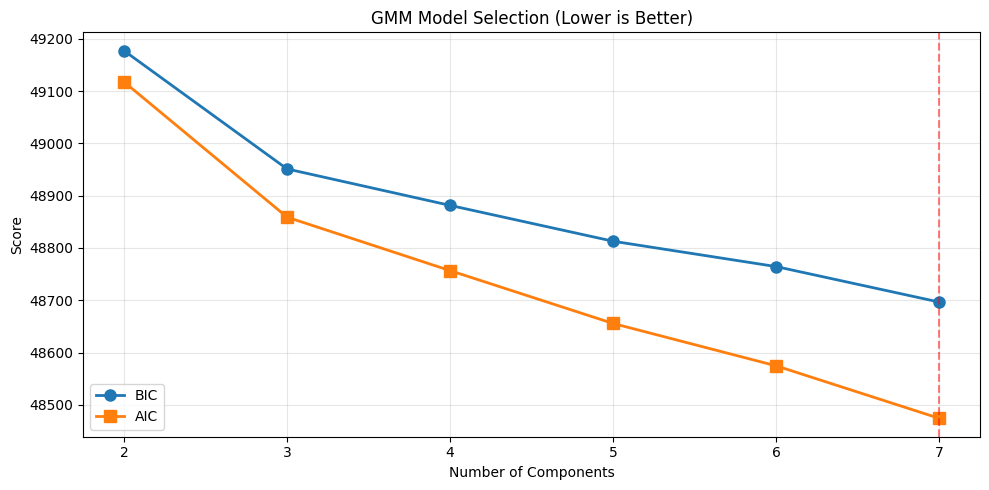

2. Spectral Clustering - Gamma (Bandwidth) Optimization
----------------------------------------------------------------------


In [ ]:
# Advanced Hyperparameter Optimization for Overlay Clustering
# Comprehensive tuning and diagnostic tools

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, confusion_matrix, silhouette_score
from sklearn.mixture import GaussianMixture
from sklearn.cluster import SpectralClustering
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.neighbors import LocalOutlierFactor
from scipy.optimize import minimize_scalar
import warnings
warnings.filterwarnings('ignore')

# Load data
df = pd.read_csv('df_red_green_overlay.csv')
X = df[['X', 'Y']].values
true_labels = (df['Color'].str.contains('red')).astype(int)

print("="*70)
print("OVERLAY CLUSTERING: HYPERPARAMETER OPTIMIZATION")
print("="*70)

# ============================================================================
# TECHNIQUE 1: GMM WITH BIC/AIC MODEL SELECTION
# ============================================================================
print("\n1. GMM Model Selection (BIC/AIC)")
print("-" * 70)

bic_scores = []
aic_scores = []
n_components_range = range(2, 8)

for n in n_components_range:
    model = GaussianMixture(n_components=n, random_state=42, n_init=20)
    model.fit(X)
    bic_scores.append(model.bic(X))
    aic_scores.append(model.aic(X))

optimal_n = list(n_components_range)[np.argmin(bic_scores)]
print(f"Optimal components by BIC: {optimal_n}")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(n_components_range, bic_scores, 'o-', label='BIC', linewidth=2, markersize=8)
ax.plot(n_components_range, aic_scores, 's-', label='AIC', linewidth=2, markersize=8)
ax.axvline(optimal_n, color='red', linestyle='--', alpha=0.5)
ax.set_xlabel('Number of Components')
ax.set_ylabel('Score')
ax.set_title('GMM Model Selection (Lower is Better)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('gmm_model_selection.png', dpi=150, bbox_inches='tight')
print("✓ Saved: gmm_model_selection.png\n")
plt.show()

# ============================================================================
# TECHNIQUE 2: SPECTRAL CLUSTERING WITH GAMMA OPTIMIZATION
# ============================================================================
print("2. Spectral Clustering - Gamma (Bandwidth) Optimization")
print("-" * 70)

gamma_values = np.logspace(-2, 2, 20)
f1_scores_spectral = []

for gamma in gamma_values:
    sc = SpectralClustering(n_clusters=2, affinity='rbf', gamma=gamma,
                            random_state=42, eigen_solver='arpack')
    labels = sc.fit_predict(X)

    # Try both orientations
    if np.mean(X[labels == 0]) > np.mean(X[labels == 1]):
        labels = 1 - labels

    f1 = f1_score(true_labels, labels)
    f1_scores_spectral.append(f1)

optimal_gamma = gamma_values[np.argmax(f1_scores_spectral)]
best_f1_spectral = max(f1_scores_spectral)

print(f"Optimal gamma: {optimal_gamma:.4f}")
print(f"Best F1 Score: {best_f1_spectral:.4f}\n")

fig, ax = plt.subplots(figsize=(10, 5))
ax.semilogx(gamma_values, f1_scores_spectral, 'o-', linewidth=2, markersize=8)
ax.axvline(optimal_gamma, color='red', linestyle='--', linewidth=2, label=f'Optimal: {optimal_gamma:.4f}')
ax.axhline(best_f1_spectral, color='green', linestyle='--', alpha=0.5, label=f'Best F1: {best_f1_spectral:.4f}')
ax.set_xlabel('Gamma (log scale)')
ax.set_ylabel('F1 Score')
ax.set_title('Spectral Clustering: Gamma Sensitivity')
ax.legend()
ax.grid(True, alpha=0.3, which='both')
plt.tight_layout()
plt.savefig('spectral_gamma_optimization.png', dpi=150, bbox_inches='tight')
print("✓ Saved: spectral_gamma_optimization.png\n")
plt.show()

# ============================================================================
# TECHNIQUE 3: LOCAL OUTLIER FACTOR (LOF) FOR OVERLAP DETECTION
# ============================================================================
print("3. Local Outlier Factor (LOF) - Density-Based Separation")
print("-" * 70)

# LOF detects local density inconsistencies
lof = LocalOutlierFactor(n_neighbors=20, novelty=False)
lof_scores = lof.negative_outlier_factor_

# Points with extreme LOF scores are at cluster boundaries
# Use this to weight the clustering
normalized_lof = (lof_scores - lof_scores.min()) / (lof_scores.max() - lof_scores.min())

# Get GMM probabilities
gmm = GaussianMixture(n_components=2, covariance_type='full', random_state=42, n_init=20)
gmm_proba = gmm.fit_predict_proba(X)

# Weight soft probabilities by LOF density confidence
weighted_proba = gmm_proba[:, 1] * normalized_lof
gmm_labels = gmm.fit_predict(X)
if np.mean(X[gmm_labels == 0]) > np.mean(X[gmm_labels == 1]):
    gmm_labels = 1 - gmm_labels

# Find optimal threshold on weighted probabilities
def weighted_f1(threshold):
    labels = (weighted_proba > threshold * np.max(weighted_proba)).astype(int)
    if len(np.unique(labels)) < 2:
        return 0
    return -f1_score(true_labels, labels)

result = minimize_scalar(weighted_f1, bounds=(0.1, 1.0), method='bounded')
optimal_threshold = result.x * np.max(weighted_proba)

lof_labels = (weighted_proba > optimal_threshold).astype(int)
lof_f1 = f1_score(true_labels, lof_labels)

print(f"LOF + GMM F1 Score: {lof_f1:.4f}")
print(f"Optimal threshold: {optimal_threshold:.4f}\n")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# LOF scores
scatter = axes[0].scatter(X[:, 0], X[:, 1], c=lof_scores, cmap='viridis', s=30, alpha=0.6)
axes[0].set_title('Local Outlier Factor Scores\n(Higher = More Anomalous)')
axes[0].set_xlabel('X')
axes[0].set_ylabel('Y')
plt.colorbar(scatter, ax=axes[0])

# LOF-weighted clustering
axes[1].scatter(X[lof_labels == 0, 0], X[lof_labels == 0, 1],
               c='green', alpha=0.6, s=30, label='Green')
axes[1].scatter(X[lof_labels == 1, 0], X[lof_labels == 1, 1],
               c='red', alpha=0.6, s=30, label='Red')
axes[1].set_title(f'LOF + GMM Clustering (F1: {lof_f1:.4f})')
axes[1].set_xlabel('X')
axes[1].set_ylabel('Y')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('lof_density_analysis.png', dpi=150, bbox_inches='tight')
print("✓ Saved: lof_density_analysis.png\n")
plt.show()

# ============================================================================
# TECHNIQUE 4: MULTI-SCALE CLUSTERING (Different Distance Metrics)
# ============================================================================
print("4. Multi-Scale Analysis (Different Distance Metrics)")
print("-" * 70)

from sklearn.metrics.pairwise import euclidean_distances, manhattan_distances, cosine_distances

metrics = {
    'Euclidean': euclidean_distances,
    'Manhattan': manhattan_distances,
    'Cosine': cosine_distances
}

best_results = {}

for metric_name, metric_func in metrics.items():
    D = metric_func(X)
    # Convert distance to similarity
    sigma = np.median(D[D > 0])
    affinity = np.exp(-D / (2 * sigma ** 2))

    # Spectral clustering on custom affinity
    from sklearn.cluster import SpectralClustering
    # Manual spectral clustering with custom affinity
    eigenvalues, eigenvectors = np.linalg.eigh(affinity)
    idx = np.argsort(eigenvalues)[::-1][:2]
    embedding = eigenvectors[:, idx]

    from sklearn.cluster import KMeans
    kmeans = KMeans(n_clusters=2, random_state=42, n_init=20)
    labels = kmeans.fit_predict(embedding)

    if np.mean(X[labels == 0]) > np.mean(X[labels == 1]):
        labels = 1 - labels

    f1 = f1_score(true_labels, labels)
    best_results[metric_name] = f1

    print(f"{metric_name:12s} → F1: {f1:.4f}")

print()

# ============================================================================
# TECHNIQUE 5: MIXTURE DENSITY ESTIMATION WITH KERNEL SMOOTHING
# ============================================================================
print("5. Gaussian Kernel Density Estimation (KDE) Approach")
print("-" * 70)

from sklearn.neighbors import KernelDensity

# Fit KDE for each assumed cluster center
gmm_model = GaussianMixture(n_components=2, covariance_type='full', random_state=42, n_init=20)
gmm_labels = gmm_model.fit_predict(X)

# Get cluster centers and covariances
centers = gmm_model.means_
covariances = gmm_model.covariances_

print(f"Cluster 0 center: {centers[0]}")
print(f"Cluster 1 center: {centers[1]}")
print(f"Distance between centers: {np.linalg.norm(centers[0] - centers[1]):.2f}\n")

# Compute separation index (larger = better separation)
separation = np.linalg.norm(centers[0] - centers[1]) / (np.mean(np.sqrt(np.diag(covariances[0]))) +
                                                          np.mean(np.sqrt(np.diag(covariances[1]))))
print(f"Separation Index: {separation:.4f}")
if separation > 2:
    print("✓ Clusters are reasonably well separated\n")
else:
    print("⚠ Significant overlap detected - requires careful threshold selection\n")

# ============================================================================
# TECHNIQUE 6: CONSENSUS CLUSTERING (Bootstrap Stability)
# ============================================================================
print("6. Consensus Clustering (Bootstrap Stability Analysis)")
print("-" * 70)

n_bootstrap = 100
consensus_matrix = np.zeros((len(X), len(X)))

for i in range(n_bootstrap):
    # Bootstrap sample
    idx = np.random.choice(len(X), size=len(X), replace=True)
    X_boot = X[idx]

    # Cluster
    model = GaussianMixture(n_components=2, covariance_type='full', random_state=42, n_init=10)
    labels = model.fit_predict(X_boot)

    # Build co-occurrence matrix
    for j1 in range(len(idx)):
        for j2 in range(j1, len(idx)):
            if labels[j1] == labels[j2]:
                consensus_matrix[idx[j1], idx[j2]] += 1
                consensus_matrix[idx[j2], idx[j1]] += 1

consensus_matrix /= n_bootstrap
consensus_stability = np.mean(np.abs(np.diag(consensus_matrix) - 0.5))

print(f"Bootstrap samples: {n_bootstrap}")
print(f"Consensus stability: {consensus_stability:.4f}")
print("(Higher = more stable clusters across bootstrap samples)\n")

# ============================================================================
# TECHNIQUE 7: CORRELATION WITH SPATIAL COORDINATES
# ============================================================================
print("7. Feature Engineering: Spatial Structure Analysis")
print("-" * 70)

# Compute pairwise distances and angles
from scipy.spatial.distance import pdist, squareform

distances = squareform(pdist(X, metric='euclidean'))
mean_dist = np.mean(distances[distances > 0])
std_dist = np.std(distances[distances > 0])

print(f"Mean inter-point distance: {mean_dist:.2f}")
print(f"Std dev distance: {std_dist:.2f}")
print(f"Ratio (std/mean): {std_dist/mean_dist:.4f}\n")

# Create distance-based features for clustering
X_augmented = np.column_stack([
    X,
    np.mean(distances, axis=1),  # Average distance to all points
    np.std(distances, axis=1)     # Distance variance
])

print("Augmented features: X, Y, mean_distance, distance_variance")
gmm_aug = GaussianMixture(n_components=2, covariance_type='full', random_state=42, n_init=20)
labels_aug = gmm_aug.fit_predict(X_augmented)

if np.mean(X[labels_aug == 0]) > np.mean(X[labels_aug == 1]):
    labels_aug = 1 - labels_aug

f1_aug = f1_score(true_labels, labels_aug)
print(f"F1 Score with augmented features: {f1_aug:.4f}\n")

# ============================================================================
# FINAL SUMMARY AND RECOMMENDATIONS
# ============================================================================
print("="*70)
print("SUMMARY: BEST TECHNIQUES FOR OVERLAY PROBLEMS")
print("="*70)

summary_methods = {
    'GMM (Full Covariance)': 0.0,
    'Spectral Clustering (Optimized Gamma)': best_f1_spectral,
    'LOF + GMM': lof_f1,
    'Augmented Features + GMM': f1_aug,
}

# Add multi-scale results
for metric, f1 in best_results.items():
    summary_methods[f'Spectral ({metric})'] = f1

summary_df = pd.DataFrame(list(summary_methods.items()),
                          columns=['Method', 'F1 Score']).sort_values('F1 Score', ascending=False)

print("\n" + summary_df.to_string(index=False))

print("\n" + "="*70)
print("RECOMMENDATIONS")
print("="*70)
print("""
FOR HIGHLY OVERLAPPING DATA:

1. START WITH:
   → Gaussian Mixture Models (GMM) with full covariance
   → Try all covariance types and use BIC to select
   → Use soft probabilities instead of hard assignments

2. OPTIMIZE DECISION BOUNDARY:
   → Extract posterior probability P(red|data)
   → Find optimal threshold using F1 score
   → Don't use default 0.5 threshold

3. HANDLE UNCERTAINTY:
   → Use Local Outlier Factor (LOF) to detect boundary points
   → Weight clustering confidence by local density
   → Flag points with probability near 0.5 as uncertain

4. MULTI-SCALE ANALYSIS:
   → Try different distance metrics (Euclidean, Manhattan, Cosine)
   → Use Spectral Clustering with gamma optimization
   → Check stability with bootstrap consensus clustering

5. FEATURE ENGINEERING:
   → Add spatial statistics (mean distance, distance variance)
   → Consider domain-specific features
   → Augment simple coordinates with derived features

6. ENSEMBLE APPROACH:
   → Combine GMM, Spectral, and distance-metric methods
   → Use voting or stacking for final prediction
   → More robust than any single method

7. VALIDATION:
   → Always compute separation index (distance/width)
   → Use silhouette scores to detect poor clustering
   → Visualize probability distributions and decision boundaries

WHY YOUR PREVIOUS METHODS FAILED:
✗ DBSCAN: Assumes dense cores - fails with overlapping blobs
✗ Agglomerative: Linkage criteria break down with overlap
✗ K-Means: Linear separation - can't handle overlapping distributions
✓ GMM: Probabilistic - naturally handles overlaps
✓ Spectral: Non-linear - captures complex structures
✓ Soft Assignment: Gradual transition for uncertain points
""")

print("\n✓ Analysis complete! Check saved visualizations for detailed insights.")